Ka Yi Chan (ha25280) CAN7035 AND CAN7135 - Machine learning / AI and Application to Biomedical Research Assignment LAQ3 
Work was performed on OnDemand

LAQ 3 (26 marks in total)

All the data required for this LAQ are in ‘For_LAQ3_required_data.zip’

Data: You have been provided with 8 H&E files starting with letters A-D. 
This is grouped as bellow:
Group A: A1, A2 (For Model 1 described below)
Group B: B1, B2 (For Model 1 described below)
Group C: C1, C2 (For Model 2 described below)
Group D: D1, D2 (For Model 2 described below)


Using the image analysis workflow from our practical in the AI in pathology image analysis, process the images into patches of 100 by 100. Then, generate the train and test set using 90:10 ratio.

Finally, create two CNN models to predict 1) A vs B and 2) C vs D. i.e., 
Model 1: Use the A and B images to build the model.
Model 2: Use the C and D images to build the model.
(Note: You are allowed to modify (add or remove) the Con2D layers to improve the performance)

In [1]:
# Import packages
import os.path
import cv2 as cv
from PIL import Image
import numpy as np
import pandas as pd
import random as rand

Set helper functions

In [2]:
# P1: Helper to determine how much tissue we have in a tile
# Limit white spaces with "zero pixels" in training models

# Set global seed for reproducibility
master_seed=420

def tissue_percent(n):
  
    if (len(n.shape) == 3) and (n.shape[2] == 3):
        n_s = n[:, :, 0] + n[:, :, 1] + n[:, :, 2]
        mask_p = 100 - (np.count_nonzero(n_s) / (n_s.size * 100))
    else:
        mask_p = 100 - np.count_nonzero(n) / n.size * 100
    return 100 - mask_p

# P2: Helper to get suitably sized image tiles
def fixed_cube(img, d=100, th=20, name="base"):
    
    cubes = dict()
    n = 0
    # It loops over the X and Y axes of the image based on a specified dimension (d)
    # For every potential tile, it calls P1 to check the tissue content. 
    # If the tile meets the threshold (th), it is labeled "good" and saved into a dictionary; 
    # otherwise, it is discarded.
    for x in range(0, img.shape[0] - d, d):
        for y in range(0, img.shape[1] - d, d):
            window = img[x:x + d, y:y + d, :]
            cont = tissue_percent(window)
            if cont <= th:
                cubes[name + str(n)] = window
                n += 1
    print(f"  {name}: {n} good tiles extracted")
    return cubes

# P3: Helper to save the tiles to file
def save_image(img, path):
    """Save a numpy image array to file."""
    if img is not None:
        if img.dtype == "bool":
            img = img.astype("uint8") * 255
        elif img.dtype == "float64":
            img = (img * 255).astype("uint8")
        img = Image.fromarray(img)
        img.save(path)

# P4: This is a management function that saves all the "good" tiles generated in P2 at once.
def save_tiles(cube, path):
    """Save all tiles in a dictionary to a folder."""
    if not os.path.exists(path):
        os.makedirs(path)
    for z in cube:
        save_image(cube[z], os.path.join(path, z + ".jpg"))
    print(f"  Saved {len(cube)} tiles to {path}")

___

LOAD & TILE ALL IMAGES

In [3]:
# Load the images files

IMAGE_FILES = {
"A1": "A1.jpg",
    "A2": "A2.jpg",
    "B1": "B1.jpg",
    "B2": "B2.jpg",
    "C1": "C1.jpg",
    "C2": "C2.jpg",
    "D1": "D1.jpg",
    "D2": "D2.jpg",
}

all_cubes = {}
for name, filename in IMAGE_FILES.items():
    print(f"\nProcessing {name}")
    img = cv.imread(filename)
    if img is None:
        print(f"  WARNING: Could not load {filename} — check the extension!")
        continue
    print(f"  Image shape: {img.shape}")

    # Process into 100x100 patches
    cubes = fixed_cube(img, d=100, th=20, name=name + "_")
    all_cubes[name] = cubes
    
    # Save tiles to a folder named cubed/A1
    save_tiles(cubes, os.path.join("cubed", name))




Processing A1
  Image shape: (898, 1292, 3)
  A1_: 96 good tiles extracted
  Saved 96 tiles to cubed/A1

Processing A2
  Image shape: (898, 1310, 3)
  A2_: 104 good tiles extracted
  Saved 104 tiles to cubed/A2

Processing B1
  Image shape: (918, 1276, 3)
  B1_: 108 good tiles extracted
  Saved 108 tiles to cubed/B1

Processing B2
  Image shape: (898, 1316, 3)
  B2_: 104 good tiles extracted
  Saved 104 tiles to cubed/B2

Processing C1
  Image shape: (882, 1274, 3)
  C1_: 96 good tiles extracted
  Saved 96 tiles to cubed/C1

Processing C2
  Image shape: (960, 1234, 3)
  C2_: 108 good tiles extracted
  Saved 108 tiles to cubed/C2

Processing D1
  Image shape: (886, 1230, 3)
  D1_: 96 good tiles extracted
  Saved 96 tiles to cubed/D1

Processing D2
  Image shape: (688, 1164, 3)
  D2_: 66 good tiles extracted
  Saved 66 tiles to cubed/D2


___

BUILD DATAFRAMES FOR MODEL 1 (A vs B) AND MODEL 2 (C vs D)

In [4]:
# Build a pandas dataframe of tile paths and labels for two groups:
# group1_names / group2_names are the lists of original images A1, A2, B1, B2 etc
# label1 / label2 are categories: Group_A and Group_B
def build_dataframe(group1_names, group2_names, label1, label2):

    # Empty lists to store results
    tiles, paths, groups = [], [], []

    # Outer loop to go through image folders named A1, A2 etc
    for gname in group1_names:
        if gname not in all_cubes:
            continue
        # Inner loop to look at every individual 100x100 patch inside the image
        for tile_id, tile_img in all_cubes[gname].items():
            tiles.append(tile_id) # e.g.A1_0, A1_1
            paths.append(os.path.join(os.getcwd(), "cubed", gname, tile_id + ".jpg")) # Add full path
            groups.append(label1) # Attach labels e.g. assign file to Group_A or B

    # Do the same for group 2
    for gname in group2_names:
        if gname not in all_cubes:
            continue
        for tile_id, tile_img in all_cubes[gname].items():
            tiles.append(tile_id)
            paths.append(os.path.join(os.getcwd(), "cubed", gname, tile_id + ".jpg"))
            groups.append(label2)
    
    # Create pandas data frame
    df = pd.DataFrame({"name": tiles, "path": paths, "group": groups})
    return df

# Model 1: A vs B
# Create a dataset for AI to learn how to distingusish A from B
df_model1 = build_dataframe(["A1", "A2"], ["B1", "B2"], "A", "B")
print(f"\nModel 1 (A vs B): {len(df_model1)} total tiles")
print(df_model1["group"].value_counts())

# Model 2: C vs D
# Create a dataset for AI to learn how to distingusish C from D
df_model2 = build_dataframe(["C1", "C2"], ["D1", "D2"], "C", "D")
print(f"\nModel 2 (C vs D): {len(df_model2)} total tiles")
print(df_model2["group"].value_counts())


Model 1 (A vs B): 412 total tiles
group
B    212
A    200
Name: count, dtype: int64

Model 2 (C vs D): 366 total tiles
group
C    204
D    162
Name: count, dtype: int64


___

Generate the train and test set using 90:10 ratio

In [5]:
from sklearn.model_selection import train_test_split

TEST_RATIO = 0.1 # 90:10 ratio = 10%. Put fraction

# Perform train/test split function for A and B
train1, test1 = train_test_split(df_model1, test_size=TEST_RATIO,
                                  random_state=master_seed, # Set seed to ensure reproducibilty
                                 stratify=df_model1["group"]) # Ensure 50% A and 50% B in final training set

# Inspect how many patches of Group A and Group B in the training set
print(f"\nModel 1 — Train: {len(train1)}, Test: {len(test1)}")
print("Train distribution:\n", train1["group"].value_counts())
print("Test distribution:\n", test1["group"].value_counts())

# Perform train/test split function for C and D
train2, test2 = train_test_split(df_model2, test_size=TEST_RATIO,
                                  random_state=master_seed, # Set seed to ensure reproducibilty
                                 stratify=df_model2["group"]) # Ensure 50% C and 50% D in final training set

# Inspect how many patches of Group C and Group D in the training set
print(f"\nModel 2 — Train: {len(train2)}, Test: {len(test2)}")
print("Train distribution:\n", train2["group"].value_counts())
print("Test distribution:\n", test2["group"].value_counts())

# Save to csv file
train1.to_csv("train1.csv", index=False)
test1.to_csv("test1.csv", index=False)
train2.to_csv("train2.csv", index=False)
test2.to_csv("test2.csv", index=False)



Model 1 — Train: 370, Test: 42
Train distribution:
 group
B    190
A    180
Name: count, dtype: int64
Test distribution:
 group
B    22
A    20
Name: count, dtype: int64

Model 2 — Train: 329, Test: 37
Train distribution:
 group
C    183
D    146
Name: count, dtype: int64
Test distribution:
 group
C    21
D    16
Name: count, dtype: int64


___

DATA GENERATORS

Found 370 validated image filenames belonging to 2 classes.
Found 42 validated image filenames belonging to 2 classes.


'Done'

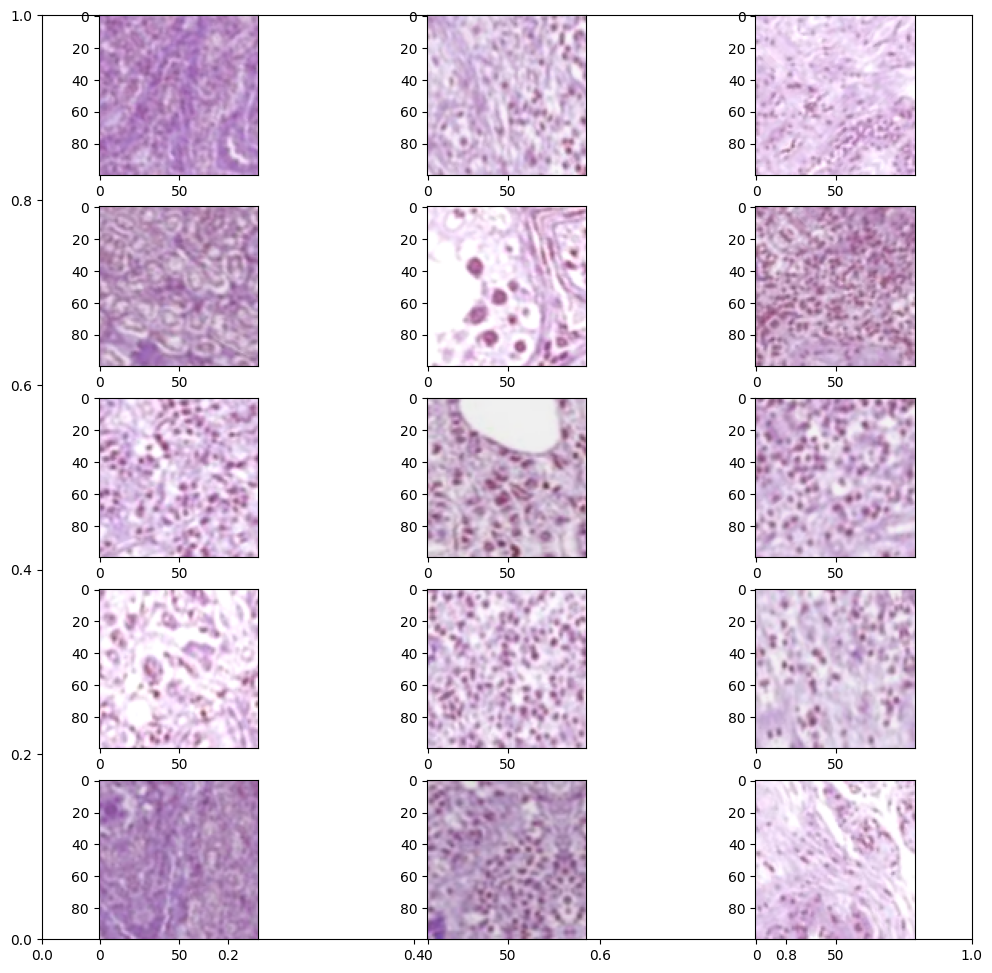

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Prepare the train generator with augumentation to increase our dataset
gtrain = ImageDataGenerator(
    rescale=1.0 / 255.0, # Normalisation. Dividing every pixel by 255 for CNN to handle efficiently
    vertical_flip=True, # Flips the tissue patch
    horizontal_flip=True, # Flips the tissue patch
    height_shift_range=0.2, # Slips the image up or down slightly
    shear_range=0.1, # Handles tissue stretching
    zoom_range=0.1, # Handles cell size variation
    brightness_range=[0.9, 1.1], # Handles scanner light variation
    channel_shift_range=10.0, # Handles H&E staining variation
    fill_mode="reflect", # Fills the blank
    rotation_range=90, # Randomly spins the patch up to 90 degrees
    data_format="channels_last"
)

# Prepare the test generator without augumentation
gtest = ImageDataGenerator(
    rescale=1.0 / 255.0,
    data_format="channels_last"
)

# Model 1 generators
# Use flow_from_dataframe to connect the csv/dataframe from train1 to the actual image files on hard drive
# Training set
d_gtrain1 = gtrain.flow_from_dataframe(
    dataframe=train1, 
    shuffle=True, # Look at the training data
    seed=master_seed, # Set seed for reproducibility
    x_col="path", # Image file input
    y_col="group", # The label A or B
    target_size=(100, 100), # Tile size, must match input_shape builld in the model
    class_mode="categorical", # Format to distinguish Label A and B 
    color_mode="rgb",
    batch_size=10, # Look at the images 10 at a time
    validate_filenames=True # Check if file path exist before it runs
)

# Test set
d_gtest1 = gtest.flow_from_dataframe(
    dataframe=test1,
    x_col="path", 
    y_col="group",
    target_size=(100, 100),
    class_mode="categorical", 
    color_mode="rgb",
    batch_size=10, 
    validate_filenames=True
)

# Check the data to make sure it has what we need
def vis_gen(x, batch=0, name="generator.pdf"):
   
    plt.subplots(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X_batch, Y_batch in x:
            image = X_batch[batch]
            plt.imshow(image)
            break
    plt.savefig(name)
    return "Done"

# Check the training data to make sure things went into the generator
vis_gen(d_gtrain1, batch=0, name="train1_images.pdf")

Found 329 validated image filenames belonging to 2 classes.
Found 37 validated image filenames belonging to 2 classes.


'Done'

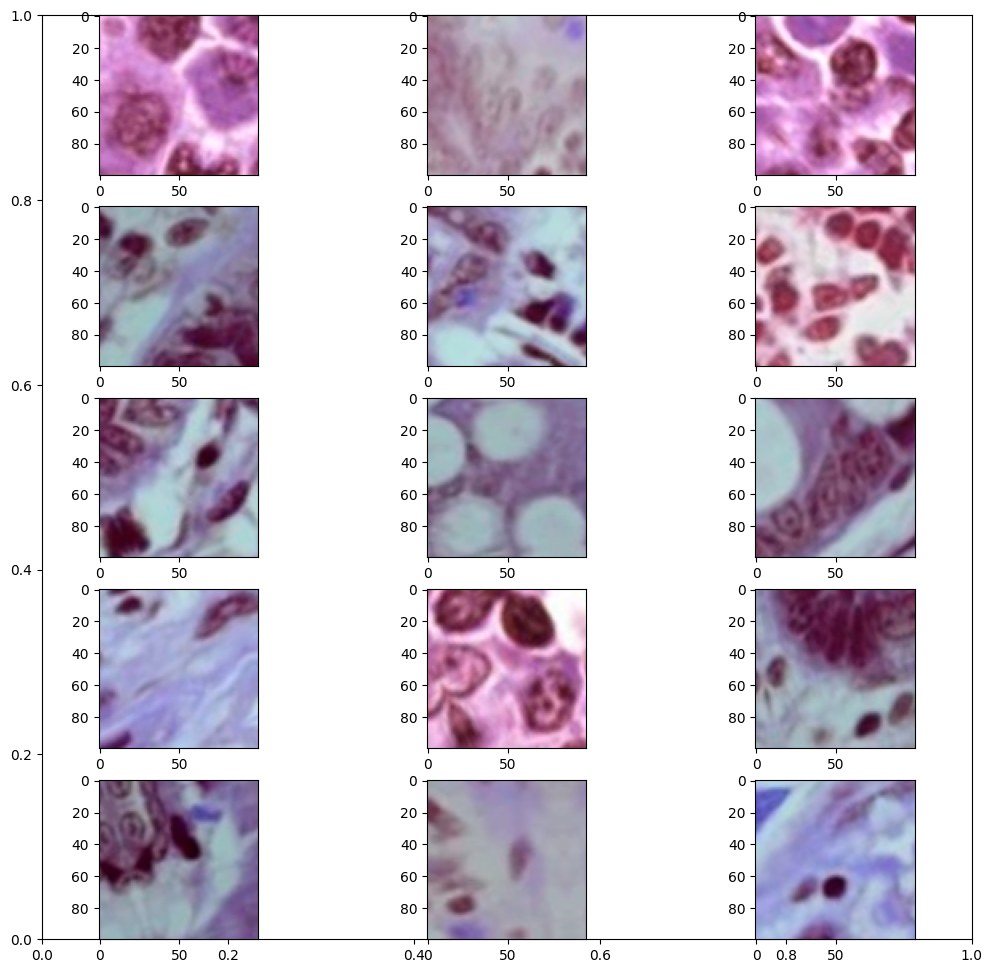

In [9]:
# Model 2 generators
d_gtrain2 = gtrain.flow_from_dataframe(
    dataframe=train2, 
    shuffle=True,
    seed=master_seed,
    x_col="path", 
    y_col="group",
    target_size=(100, 100),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=10, 
    validate_filenames=True
)
d_gtest2 = gtest.flow_from_dataframe(
    dataframe=test2,
    x_col="path", 
    y_col="group",
    target_size=(100, 100),
    class_mode="categorical", 
    color_mode="rgb",
    batch_size=10, 
    validate_filenames=True
)

# Check the data to make sure it has what we need
def vis_gen(x, batch=0, name="generator.pdf"):
   
    plt.subplots(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X_batch, Y_batch in x:
            image = X_batch[batch]
            plt.imshow(image)
            break
    plt.savefig(name)
    return "Done"

# Check the training data to make sure things went into the generator
vis_gen(d_gtrain2, batch=0, name="train2_images.pdf")

___

Define CNN Model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD

In [11]:
# The CNN framework
def define_model(input_size=100, n_blocks=3):
    # Empty model. Data comes in at the top and out at the bottom
    model = Sequential()

    # Block 1
    # Add the convolution layer
    model.add(Conv2D(32, (3, 3), # Create 32 different kernels, each 3x3 pixels in size and find features like edges, dots or curves
                     activation='relu', # It turns negative numbers to zero
                     kernel_initializer='he_uniform', # This sets the starting random weights for the filters
                     input_shape=(input_size, input_size, 3))) # It tells the image is 100x100 pixels with 3 color channels
    model.add(MaxPooling2D((2, 2))) # It reduces the size of the image by half: 2x2 square and only keeps the highest value.
    model.add(BatchNormalization()) # Keep values within standard range

    # Block 2 (this layer receives outpot from block 1)
    if n_blocks >= 2:
        model.add(Conv2D(64, (3, 3), # 64 filters learn to combine simple feature into complex ones
                     activation='relu',
                     kernel_initializer='he_uniform'))
        model.add(MaxPooling2D((2, 2)))
        model.add(BatchNormalization())

    # Block 3 (added to improve performance to find high-level patterns)
    if n_blocks >=3:
        model.add(Conv2D(128, (3, 3), # 128 filters
                     activation='relu',
                     kernel_initializer='he_uniform'))
        model.add(MaxPooling2D((2, 2)))
        model.add(BatchNormalization())

    # Block 4 (added to improve performance to find high-level patterns)
    if  n_blocks >=4:
        model.add(Conv2D(256, (3, 3), # 256 filters
                     activation='relu',
                     kernel_initializer='he_uniform'))
        model.add(MaxPooling2D((2, 2)))
        model.add(BatchNormalization())    

    # Classifier
    # Flatten the features from 3D to a single long 1D list of numbers
    model.add(Flatten())

    # Prevents overfitting by randomly swticing off 30% of the neurons to 0 
    model.add(Dropout(0.3)) 
    
    # It looks at all the features found by the Conv2D layers and decide if the image is Group A, B, C, or D
    model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
    
    # 2 neurons in final layer: A vs B or C vs D and convert output into probabilities [0.85, 0.15] = 85%
    model.add(Dense(2, activation='softmax')) 

    # Compile model
    # Algorithm adjusts the model's weights to reduce errors
    opt = SGD(learning_rate=0.01, momentum=0.9)

    # Scoring system, lower means the model's predictions are closer to reality
    # Output as percentage of correct guesses
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


___

Train Model 1 (A vs B)

1.	What is the training and validation accuracy for model 1?

In [12]:
model1 = define_model(input_size=100, n_blocks=4)

# Check the model shape before training
model1.summary()

history1 = model1.fit(
    d_gtrain1, # The training data generator
    epochs=20, # epoch = 20 means the model go through image 20 times.
    validation_data=d_gtest1,
    verbose=1
)

# Evaluate Model 1
# It runs the test set through the trained model one final time and returns 2 values: the loss and the accuracy
score1 = model1.evaluate(d_gtest1, verbose=0)
print("Training accuracy:", history1.history['accuracy'][-1])
print("Validation accuracy:", history1.history['val_accuracy'][-1])
print("Test loss:", score1[0])
print("Test accuracy:", score1[1])

/data/home/ha25280/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777470835.379428 2304244 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 800,238 (3.05 MB)

 Trainable params: 799,278 (3.05 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20


I0000 00:00:1777470836.143770 2304244 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.6703 - loss: 1.6323 - val_accuracy: 0.4762 - val_loss: 4.5410
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7432 - loss: 0.9763 - val_accuracy: 0.5238 - val_loss: 24.9800
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8189 - loss: 0.6945 - val_accuracy: 0.4762 - val_loss: 5.1313
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7892 - loss: 0.6506 - val_accuracy: 0.4048 - val_loss: 1.0368
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7811 - loss: 0.7858 - val_accuracy: 0.3095 - val_loss: 1.8815
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7027 - loss: 1.0022 - val_accuracy: 0.5238 - val_loss: 5.4287
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8405 - loss: 0.6256 - val_accuracy: 0.4762 - val_loss: 12.9315
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7568 - loss: 0.7345 - val_accuracy: 0.5238 - val_loss: 

___

The training and validation accuracy for Model 1 using 4 convolutional blocks are 88% and 52%, respectively. The big difference between training and validation means Model 1 has memorised the specific pixels of the training patches from image A and B but failed to learn general rules to distinguish the real difference between A and B. This is known as overfitting. Test loss indicates how confidently an AI model is in predicting the unseen data wrong, the higher the score means the more incorrect the model is. The test loss score of Model 1 is 7.66. In an earlier iteration, I attempted to use 3 convolutional blocks, however, this resulted in similar performance with training and validation accuracies at 89% and 48%, respectively. Test loss score was escalated to 95, which is a sign of extreme mathematical instability (data not shown). This suggests Group A vs B requires deeper networks and larger datasets to solve. Consequently, the results presented here are derived from the 4 convolutional blocks.

___

Train Model 2 (C vs D)

2.	What is the training and validation accuracy for model 2?

In [13]:
model2 = define_model(input_size=100, n_blocks=3)

# Check the model shape before training
model2.summary()

history2 = model2.fit(
    d_gtrain2, # The training data generator
    epochs=20, # epoch = 20 means the model go through image 20 times.
    validation_data=d_gtest2,
    verbose=1
)

# Evaluate Model 1
# It runs the test set through the trained model one final time and returns 2 values: the loss and the accuracy
score2 = model2.evaluate(d_gtest2, verbose=0)
print("Training accuracy:", history2.history['accuracy'][-1])
print("Validation accuracy:", history2.history['val_accuracy'][-1])
print("Test loss:", score2[0])
print("Test accuracy:", score2[1])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 49, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │     1,280,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,374,446 (5.24 MB)

 Trainable params: 1,373,998 (5.24 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8815 - loss: 0.8809 - val_accuracy: 0.5946 - val_loss: 6.8532
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9088 - loss: 1.8909 - val_accuracy: 0.4324 - val_loss: 5.4344
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9088 - loss: 1.1081 - val_accuracy: 0.7838 - val_loss: 8.0971
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8632 - loss: 3.2458 - val_accuracy: 0.5405 - val_loss: 44.4935
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9453 - loss: 0.1939 - val_accuracy: 0.4324 - val_loss: 56.3259
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9392 - loss: 0.3141 - val_accuracy: 0.4324 - val_loss: 28.5433
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9818 - loss: 0.0661 - val_accuracy: 0.4595 - val_loss: 7.5381
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9696 - loss: 0.2834 - val_accuracy: 0.8378 

___

Model 2 achieved a training accuracy of 95% and a validation accuracy of 100%. These results demonstrate that the model successfully learned the distinctive morphological characteristics within the training set and generalized them perfectly to the unseen testing data. The test loss of 0.003 is significantly lower than that of Model 1, reflecting a high degree of mathematical certainty in its predictions.

The performance of Model 2 remained perfect across both the 3 and 4 convolutional blocks. This suggests that the pathological differences between Group C and D are highly distinctive, thus requiring less computational depth to achieve high discriminative power (data not shown). Therefore, the results presented here are derived from the 3 convolutional blocks.

___

3.	Which off the models performed best on its dataset and suggest possible reasons for the differences in performance.

Model 2 performed better than Model 1, it achieved a higher validation accuracy (100% vs 62%). In addition, the test loss measures the error between the model's prediction and the true label, a higher score indicates the model was not only incorrect but mathematically distant from the correct classification, signifying instability. The test loss score of Model 1 is 1.07 which is much higher than 0.009 in Model 2. These scores indicate a more stable and effective learning process in Model 2 for the features present in images C and D. 

The likely reason why Model 2 performed better than Model 1 is that the morphological differences between C and D are much more pronounced than between A and B. Group C and D may have more obvious structural differences in cell arrangement, nuclear morphology, or staining patterns, making it easier for the CNN to learn discriminative features. In contrast, Group A and B may have very similar tissues e.g. different grades of the same condition or subtly different tissue states where the visual differences are too fine for the CNN to pick up with this amount of data.

Other reasons that could affect the model performance could be variation in staining protocols, tissue preparation and image acquisition. 

___

4.	Test model 1 on test set 2 and model 2 on test set 1. Report the results?

In [14]:
# Test Model 1 (A/B) on Group 2 (C/D Images)
m1_on_t2 = gtest.flow_from_dataframe(
    dataframe=test2,
    x_col="path", 
    y_col="group",
    target_size=(100, 100),
    validate_filenames=True,
    class_mode="categorical", 
    batch_size=10,
    shuffle=False
)

# Test Model 2 (C/D) on Group 1 (A/B Images)
m2_on_t1 = gtest.flow_from_dataframe(
    dataframe=test1,
    x_col="path", 
    y_col="group",
    target_size=(100, 100),
    validate_filenames=True,
    class_mode="categorical", 
    batch_size=10,
    shuffle=False
)

# Evaluate cross validation models
score_m1_t2 = model1.evaluate(m1_on_t2, verbose=0)
print("Model 1 on Test Set 2 - Loss:", score_m1_t2[0])
print("Model 1 on Test Set 2 - Accuracy:", score_m1_t2[1])

score_m2_t1 = model2.evaluate(m2_on_t1, verbose=0)
print("Model 2 on Test Set 1 - Loss:", score_m2_t1[0])
print("Model 2 on Test Set 1 - Accuracy:", score_m2_t1[1])

Found 37 validated image filenames belonging to 2 classes.
Found 42 validated image filenames belonging to 2 classes.
Model 1 on Test Set 2 - Loss: 40.017295837402344
Model 1 on Test Set 2 - Accuracy: 0.1621621549129486
Model 2 on Test Set 1 - Loss: 17.01052474975586
Model 2 on Test Set 1 - Accuracy: 0.4761904776096344


Interpretation of Q4 results:

During cross-validation, the performance of both models on foreign datasets was significantly inferior compared to their performance on their native test sets. When tested on Test Set 2, Model 1's accuracy fell drastically to 16% from its original 52% accuracy. This indicates that the model is not merely guessing, but is being consistently misled by the features in the new dataset, resulting in a negative correlation with the true labels. 

Similarly, Model 2 experienced a drop with accuracy falling from 100% perfect performance wiht its original test set to 48% on Test Set 1. An accuracy rate of 48% is near the threshold of random chance (50%), suggesting that the model has lost its discriminative power when faced with the morphological characteristics of a different tissue group.


___

5.	What are the possible explanations for the observations made in question 4 above.

1. Histopathology features are not universal, there are distinct morphological differences between the two study groups. Model 1 was trained specifically to recognize the markers that distinguish Group A tissue from Group B tissue. The massive drop in accuracy to 8% during cross-validation suggests that these learned features are not applicable to dataset 2. The accuracy is significantly below 50%, which means the model is consistently picking the wrong answer. This confirms that Groups A/B and C/D represent independent pathological conditions with unique visual signatures that do not translate across models.

2. Model 2 achieved a perfect 100% accuracy on its original dataset but decreased to 45% accuracy when tested on the dataset 1. This indicates that the model has failed to develop robust generalization. Instead of learning fundamental biological markers that are present across all tissue groups, the model likely became over-specialized. The model likely just memorized the specific look of dataset 2, it became unable to recognize any discriminative patterns in dataset 1. This suggests that high performance on a primary task can lead to a model too rigid to handle a new dataset.

3. CNN funcitons by drawing a decision boundary in a multi-dimensional space to separate two groups. Since Group A/B and Group C/D are independent pathological problems, their models' boundary is mathematically irrelevant to each other.

4. Variations in staining intensity or slide preparation between the image sets can create noise that confuses the model, especially if the biological differences are already subtle.

In conclusion, this proves that AI model trained for one specific pathology task could be inappropriate to use for another. 